In [1]:
import os
import json
import pickle
import pathlib
import numpy as np
import scipy.interpolate as interp
import tqdm #looked cool
import mat73 as matloader

import numpy as np
import scipy.interpolate as interp
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import tkinter as tk

import pandas as pd

# https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset , tensors can be used in the dataloader , good stuff!!
from torch.utils.data import TensorDataset, DataLoader

In [2]:
def win_loader(Folder_Name : str):
    drive_letter = 'A'
    for i in range(26):
        loc_try = chr(ord(drive_letter)+i) + ":\\" + Folder_Name
        if os.path.exists(loc_try):
            return loc_try
    raise Exception(f"No drive with {Folder_Name} folder found")

dir = r"/Volumes/ESSD/BatteryLife" if os.name == 'posix' else win_loader(r"BatteryLife") 
print(dir)
print(os.path.dirname(dir))

E:\BatteryLife
E:\


        raw_time = np.array(data['cycle_data'][i]['time_in_s'])
        scaled_time = raw_time - raw_time[0]
        raw_current = np.array(data['cycle_data'][i]['current_in_A'])
        raw_voltage = np.array(data['cycle_data'][i]['voltage_in_V'])

In [3]:
bigmat_file = '2019-01-24_batchdata_updated_struct_errorcorrect.mat'
bigmat_file_loc = os.path.join(os.path.dirname(dir), 'AttiaProccesed', 'EL150800716817.csv')
df = pd.read_csv(bigmat_file_loc)
print(df)


        Cycle  Test_Time   Voltage   Current  Temperature
0           1   0.000000  2.058289  0.311311    30.643936
1           1   0.000670  2.097390  0.870861    30.643438
2           1   0.001252  2.146307  1.356735    30.643005
3           1   0.001857  2.215509  1.918113    30.642555
4           1   0.002492  2.294139  2.476994    30.642082
...       ...        ...       ...       ...          ...
485043    530  50.866635  2.042958  0.000000    32.117538
485044    530  50.883235  2.074192  0.000000    32.110879
485045    530  50.899833  2.101324  0.000000    32.104220
485046    530  50.916433  2.125481  0.000000    32.097561
485047    530  50.933155  2.147277  0.000000    32.077645

[485048 rows x 5 columns]


In [4]:
trial_dict = {'cycle_data' : []}
df.rename(columns={'Cycle':'cycle_number','Test_Time': 'time_in_s', 'Voltage': 'voltage_in_V', 'Current':'current_in_A',  'Temperature':'temperature_in_C'}, inplace=True)

for i in range(df['cycle_number'].tail(1).array[0]):
    search_mask = df.loc[:,"cycle_number"] == (i+1)
    test = df[search_mask].to_dict(orient='list')
    test['cycle_number'] = (i+1)
    test['time_in_s'] = [x*60 for x in test['time_in_s']]
    trial_dict['cycle_data'].append(test)

with open(os.path.join(os.path.dirname(dir),'Trial_folder','eek.pkl'),'wb') as fie:
    pickle.dump(trial_dict,fie)


In [ ]:
class Testing():
    def __init__(self, listt):
        self.listt = listt
    def __getitem__(self, key):
        if isinstance(key, list):
            return [self.__getitem__(k) for k in key]
        if isinstance(key, int):
            return self.listt[key]
        else:           
            raise TypeError(f"Invalid key type: {type(key)}")
    
fram = pd.DataFrame({'cycle_number': [1, 1, 2, 2], 'time_in_s': [0, 60, 0, 60], 'voltage_in_V': [3.7, 3.6, 3.8, 3.7], 'current_in_A': [1.0, 0.5, 1.0, 0.5], 'temperature_in_C': [25, 26, 25, 26]})
framd = fram.to_dict(orient='list')


In [5]:
with open(os.path.join(os.path.dirname(dir),'Trial_folder','eek.pkl'),'rb') as fie:
     data =  pickle.load(fie)
for key, value in data['cycle_data'][-1].items():
    print(f"{key}: {str(value)[:100]}")

cycle_number: 530
time_in_s: [0.0, 0.031799999997018005, 0.054499999852848, 0.079799999948586, 0.11049999995157, 0.13390000001527
voltage_in_V: [2.1657381, 2.2090435, 2.2469254, 2.3033476, 2.3667822, 2.4208603, 2.5033913, 2.5439463, 2.6072435, 
current_in_A: [0.312631781818182, 0.796942281818182, 1.11483836363636, 1.51609245454545, 1.91661836363636, 2.23701
temperature_in_C: [31.9814002017684, 31.9814791257522, 31.9815354645708, 31.9815982562937, 31.9816744502026, 31.981732


In [74]:
proceddingh_folder = os.path.join(os.path.dirname(dir), 'AttiaProccesed')
content = os.listdir(proceddingh_folder)
files = [f for f in content if f.endswith(".csv")]
print(files[0][:-4])

EL150800769633


In [6]:
## List all csv's, save their names as needed for pkl saves
## Itterate over files, save each to the dicts form, save to respective pkl
## JSON were created in matlab so no need
def create_pickles(proceddingh_folder : str, dest_folder : str):
    content = os.listdir(proceddingh_folder)
    files = [f for f in content if f.endswith(".csv")]

    for idx, name in enumerate(files):
        df = pd.read_csv(os.path.join(proceddingh_folder,files[idx]))
        temp_dict = {'cycle_data' : [],'nominal_capacity_in_Ah' : 1.1}
        df.rename(columns={'Cycle':'cycle_number','Test_Time': 'time_in_s', 'Voltage': 'voltage_in_V', 'Current':'current_in_A',  'Temperature':'temperature_in_C'}, inplace=True)
        for i in range(df['cycle_number'].tail(1).array[0]):
            search_mask = df.loc[:,"cycle_number"] == (i+1)
            test = df[search_mask].to_dict(orient='list')
            test['cycle_number'] = (i+1)
            test['time_in_s'] = [x*60 for x in test['time_in_s']]
            temp_dict['cycle_data'].append(test)
        dest_file = name[:-4] + ".pkl"
        with open(os.path.join(os.path.dirname(dir),dest_folder,dest_file),'wb') as fie:
            pickle.dump(temp_dict,fie)


proceddingh_folder = os.path.join(os.path.dirname(dir), 'AttiaProccesed')
create_pickles(proceddingh_folder, 'Attia_GK')
proceddingh_folder = os.path.join(os.path.dirname(dir), 'SeversonB1Proccesed')
create_pickles(proceddingh_folder, 'Severson_B1_GK')
proceddingh_folder = os.path.join(os.path.dirname(dir), 'SeversonB2Proccesed')
create_pickles(proceddingh_folder, 'Severson_B2_GK')
proceddingh_folder = os.path.join(os.path.dirname(dir), 'SeversonB3Proccesed')
create_pickles(proceddingh_folder, 'Severson_B3_GK')


In [7]:
with open(os.path.join(dir, 'CALB', 'CALB_0_B182.pkl'), 'rb') as file:
            data = pickle.load(file)

for key, value in data['cycle_data'][0].items():
    print(f"{key}: {str(value)[:100]}")


cycle_number: 1
current_in_A: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
voltage_in_V: [4.2937, 4.2937, 4.2937, 4.2934, 4.2937, 4.2934, 4.2937, 4.2934, 4.2934, 4.2934, 4.2934, 4.2934, 4.2
charge_capacity_in_Ah: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0
discharge_capacity_in_Ah: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
time_in_s: [0.0, 30.0, 60.0, 90.0, 120.0, 150.0, 180.0, 210.0, 240.0, 270.0, 300.0, 330.0, 360.0, 390.0, 420.0,
temperature_in_C: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
internal_resistance_in_ohm: None


In [8]:

# Extracting the labels and ascociated file location containing the cycles, Tongji needed a fix since it has '-' replaced with '#' in the # JSON labels ## 
# To fix stanfords issue - appending '2' to the pkl files and the json entries 
stanford_2_dir = os.path.join(dir,'Stanford_2') 
standford_2_list = os.listdir(stanford_2_dir) 

if standford_2_list[0][0:10] == 'Stanford_N':
    for file in standford_2_list:
         new_name = file[0:9]+'2_'+ file[9:]
         try:
             os.rename(os.path.join(stanford_2_dir,file),os.path.join(stanford_2_dir,new_name))
         except:
             print("Probably already sorted")
             break


In [9]:
##Since each json file contains labels with the same folder of pickles, updated desgin now has an array with ascociated folder loc too (not size efficent but that dosent matter)
def get_dict(labels_dir):
    dict_labels = {}
    content = os.listdir(labels_dir)
    folder_locs = []
  
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(labels_dir, f), 'r') as file:
            data = json.load(file)
            if 'Tongji' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("#", "-")
                    temp_dict.update({k_new:v})
               data = temp_dict   
            if 'Stanford_2' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("Stanford_Nova", "Stanford_2_Nova")
                    temp_dict.update({k_new:v})
               data = temp_dict
            if 'Attia_GK' in f or 'Severson' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k + ".pkl"
                    temp_dict.update({k_new:v})
               data = temp_dict   
            it = next(pathlib.Path(dir).rglob(list(data.keys())[0])) #Method to get just the first files location for a givben pkl file, 
            temp = list(dict.fromkeys(list(data.keys())))
            folder_locs.extend([os.path.split(it)[0] for x in range(len(temp))])  #https://www.geeksforgeeks.org/python/python-get-unique-values-list/
            dict_labels.update(data)
            
    k = list(dict_labels.keys())
    v = list(dict_labels.values())
    folder = folder_locs
    return k, v, folder


## Returns asociated file(label_path) and labels(soh) and folder locations * files 
## Issues found that some pkl files contained duplicate keys, seems STANDFAORD_2 NOVA has same keys as standford !

labels_path = os.path.join(dir, "Life labels")
cycles_file, soh, file_dir = get_dict(labels_path)
print(f"Found {len(soh)} labels, and {len(cycles_file)} keys/files")
print(soh)
print(cycles_file)
print(file_dir)

Found 1426 labels, and 1426 keys/files
[107, 105, 176, 161, 189, 123, 164, 104, 792, 980, 1233, 1272, 1352, 1260, 1267, 1283, 1241, 1243, 1169, 1253, 1410, 1318, 1301, 1260, 997, 993, 986, 568, 519, 538, 487, 448, 473, 590, 518, 739, 534, 534, 579, 829, 266, 228, 255, 246, 263, 234, 262, 257, 259, 231, 263, 239, 247, 218, 1760, 1179, 2116, 2230, 2033, 1975, 1421, 1901, 2344, 2755, 2023, 1938, 2088, 2106, 1981, 2261, 2359, 1747, 1726, 1907, 1946, 1531, 1821, 1441, 1742, 1779, 1722, 2575, 2353, 2100, 2189, 2538, 2436, 1667, 1600, 2025, 1793, 1549, 2569, 1869, 1164, 2080, 1420, 2278, 1450, 1490, 1726, 2255, 1318, 1432, 2272, 1972, 1752, 2768, 2574, 1528, 1911, 2764, 2377, 1545, 1698, 1382, 2583, 2412, 1338, 1995, 1812, 2716, 2338, 2542, 1634, 1829, 1621, 1849, 1810, 2061, 1542, 735, 1667, 817, 1031, 779, 428, 1500, 297, 1500, 937, 448, 607, 906, 466, 614, 466, 1567, 250, 1593, 1166, 1220, 658, 3713, 665, 3211, 134, 1269, 1463, 715, 3936, 593, 653, 393, 2646, 262, 2042, 419, 444, 358, 553,

In [10]:
os.path.basename(dir)
my_dict = {'name': 2}
my_dict.keys()

dict_keys(['name'])

In [11]:
t = pathlib.Path(dir).rglob('*.pkl')
for i,v in enumerate(t):
    print(f"{i} : {v} : {os.path.split(v)[0]} : {os.path.basename(os.path.split(v)[0])}")


0 : E:\BatteryLife\CALB\CALB_0_B188.pkl : E:\BatteryLife\CALB : CALB
1 : E:\BatteryLife\CALB\CALB_25_T25-1.pkl : E:\BatteryLife\CALB : CALB
2 : E:\BatteryLife\CALB\CALB_35_B247.pkl : E:\BatteryLife\CALB : CALB
3 : E:\BatteryLife\CALB\CALB_45_B253.pkl : E:\BatteryLife\CALB : CALB
4 : E:\BatteryLife\CALB\CALB_45_B255.pkl : E:\BatteryLife\CALB : CALB
5 : E:\BatteryLife\CALB\CALB_25_T25-2.pkl : E:\BatteryLife\CALB : CALB
6 : E:\BatteryLife\CALB\CALB_45_B256.pkl : E:\BatteryLife\CALB : CALB
7 : E:\BatteryLife\CALB\CALB_35_B250.pkl : E:\BatteryLife\CALB : CALB
8 : E:\BatteryLife\CALB\CALB_35_B173.pkl : E:\BatteryLife\CALB : CALB
9 : E:\BatteryLife\CALB\CALB_35_B229.pkl : E:\BatteryLife\CALB : CALB
10 : E:\BatteryLife\CALB\CALB_35_B228.pkl : E:\BatteryLife\CALB : CALB
11 : E:\BatteryLife\CALB\CALB_35_B224.pkl : E:\BatteryLife\CALB : CALB
12 : E:\BatteryLife\CALB\CALB_35_B227.pkl : E:\BatteryLife\CALB : CALB
13 : E:\BatteryLife\CALB\CALB_35_B248.pkl : E:\BatteryLife\CALB : CALB
14 : E:\Battery

In [12]:
# Used to get the total number of labels for trainig (by summing all entries in every json file)
def get_length(dir):
    content = os.listdir(dir)
    length = 0
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(dir, f), 'r') as file:
            data = json.load(file)
            length += len(data)
    return length


In [13]:
content = os.listdir(dir)
print(f"###### \n ---- Content ---- ({content}) \n######")
folders = [f for f in content if os.path.isdir(os.path.join(dir, f)) and (f != "Life labels" and f != "READMEs") and not f.startswith("._") and not f.startswith(".DS_Store")]
pkl_files = [[] for _ in folders]
for i, folder in enumerate(folders) :
    folder_path = os.path.join(dir, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.pkl'):
            pkl_files[i].append(file)
print(len(pkl_files))

###### 
 ---- Content ---- (['CALB', 'CALCE', 'HNEI', 'HUST', 'ISU_ILCC', 'Life labels', 'MATR', 'MICH', 'MICH_EXP', 'NA-ion', 'README.md', 'READMEs', 'RWTH', 'SDU', 'SNL', 'Stanford', 'Stanford_2', 'Tongji', 'UL_PUR', 'XJTU', 'ZN-coin', '.DS_Store', 'Severson_B1_GK', 'Severson_B2_GK', 'Severson_B3_GK', 'Attia_GK']) 
######
22


In [14]:


def get_cycle_data(data, cycle_format):
    
    arr_total = np.zeros((cycle_format, 4, 300))
    
    for i in range(cycle_format):

        raw_time = np.array(data['cycle_data'][i]['time_in_s'])
        scaled_time = raw_time - raw_time[0]
        raw_current = np.array(data['cycle_data'][i]['current_in_A'])
        raw_voltage = np.array(data['cycle_data'][i]['voltage_in_V'])
        dt = np.diff(scaled_time)
        avg_current = 0.5 * (raw_current[1:] + raw_current[:-1])   # Adds nect time step onto previous (original + sited_by_one)
        cumulative_charge = np.concatenate(([0], np.cumsum(avg_current * dt) )) #My method shifts to right, so needed to add 0 at the start  
        
        capacity_Ah = cumulative_charge / 3600.0

        ## Some of the cycles I saw had starting in charging and others where starting in dishcharging, which mean the capacity values would be nonsesical
        ## thus checks are done below

        # If index of starting to charge is higher (after discharge), the chances are its discharging from 100% SoC first, so deduct peak capacity intergral from running intergral
        idx_charge = np.where((raw_current) > 0.1)[0]
        idx_discharge = np.where((raw_current) < -0.1)[0]

        if (len(idx_charge) == 0) or (len(idx_discharge) == 0):
            pass #do nothing, could be some better logic but left as is for now
        else:
            if idx_charge[0] > idx_discharge[0]: 
                capacity_Ah = np.abs(capacity_Ah.min()) + capacity_Ah

        t_new = np.linspace(0, scaled_time[-1], num=300)
        f_current = interp.interp1d(scaled_time, raw_current, kind='linear')
        f_voltage = interp.interp1d(scaled_time, raw_voltage, kind='linear')
        f_capacity = interp.interp1d(scaled_time, capacity_Ah, kind='linear')
        
        current_interpolated = f_current(t_new) / data['nominal_capacity_in_Ah']
        
        voltage_interpolated = f_voltage(t_new) # / data['max_voltage_limit_in_V']
        
        capacity_interpolated = f_capacity(t_new) / data['nominal_capacity_in_Ah']
        
        size_channel = np.full(300, data['nominal_capacity_in_Ah'])
        
        arr_total[i] = np.stack(
            (current_interpolated,
             voltage_interpolated,
             capacity_interpolated,
             size_channel), 
            axis=0
        )
    
    return arr_total


In [10]:
import numpy as np
arr = np.array([2, 20,3,7, 8, 3, 10,-51,1])
idx = np.where(arr >5)[0]
print(idx)
print(np.abs(arr.min()))
print("Even elements:", arr[idx])

[1 3 4 6]
51
Even elements: [20  7  8 10]


In [19]:
test = np.array([1,2,3,4,5,6,7,8,9])
test[1:] + test[:-1]
file_dir[-1]

'E:\\BatteryLife\\Severson_B3_GK'

In [15]:
with open(os.path.join(file_dir[-1], cycles_file[-1]), 'rb') as file:
             data = pickle.load(file)
data['cycle_data'][0]['time_in_s'][0]
 

0.0

In [16]:

local_save_dir = "./processed_tensrs" 
os.makedirs(local_save_dir, exist_ok=True)

x_path = os.path.join(local_save_dir, "X_features.pt")
y_path = os.path.join(local_save_dir, "y_labels.pt")

if os.path.exists(x_path) and os.path.exists(y_path):
    print("Loading into ram (already exits)")
    X_tensor = torch.load(x_path)
    y_tensor = torch.load(y_path)
    print("Done")

else:
    print("Tensors not found, creating...")

    all_features = []
    all_labels = []

    # Loop through all files and extract the features
    for idx in tqdm.trange(len(soh), desc="Loadibg in the files"):
        try:
            with open(os.path.join(file_dir[idx], cycles_file[idx]), 'rb') as file:
             data = pickle.load(file)
             prev_file = file_dir[idx]
        except FileNotFoundError:
           print(f"File: {cycles_file[idx]} not found, skipping")
           continue
        try:
            features = get_cycle_data(data, cycle_format=1)
        except:
           print(f"Culprit: {cycles_file[idx]}, skipping")
           continue
        if not isinstance(soh[idx], (int, float)):
           continue
        all_features.append(features)
        all_labels.append(soh[idx])

    X_tensor = torch.tensor(np.array(all_features), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.float32)

    torch.save(X_tensor, x_path)
    torch.save(y_tensor, y_path)
    
    print(f"Saved tensors to {local_save_dir}!")

print(f"Total Features Shape: {X_tensor.shape}")

max_dataset_capacity = X_tensor[:, 0, 3, :].max()
min_dataset_capacity = X_tensor[:, 0, 3, :].min()
max_dataset_voltage = X_tensor[:, 0, 1, :].max()
min_dataset_voltage = X_tensor[:, 0, 1, :].min()
max_dataset_current = X_tensor[:, 0, 0, :].max()
min_dataset_current = X_tensor[:, 0, 0, :].min()

y_max = y_tensor.max()




Loading into ram (already exits)
Done
Total Features Shape: torch.Size([1366, 1, 4, 300])


In [17]:
for i, v in enumerate(all_labels):
    if not isinstance(v, (int, float)):
        print(i, v, type(v))

NameError: name 'all_labels' is not defined

In [18]:
p = torch.tensor([[[1.,2.,3.],[2.,3.,4.],[2.,3.,6.]],[[1.,2.,3.],[2.,3.,4.],[2.,3.,9.]]])
t = p.mean((0))
t = p[:,0,:] + 5  / 32
print(t)




tensor([[1.1562, 2.1562, 3.1562],
        [1.1562, 2.1562, 3.1562]])


Stats on data--> Cap_max: 58.0, Cap_min: 0.00021888884657528251, V_max: 4.400380611419678 V_min: -0.004999999888241291 I_max: 10.801191329956055 I_min: -10.801445007324219


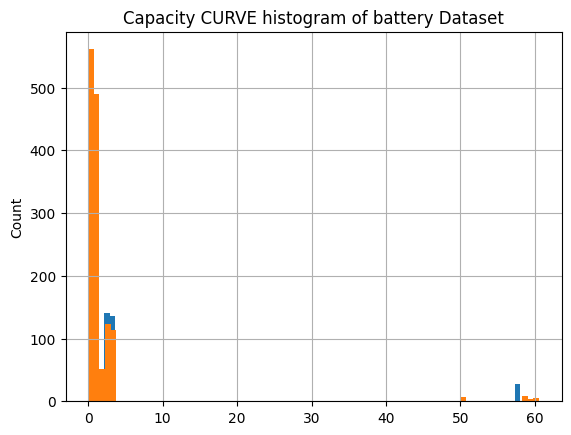

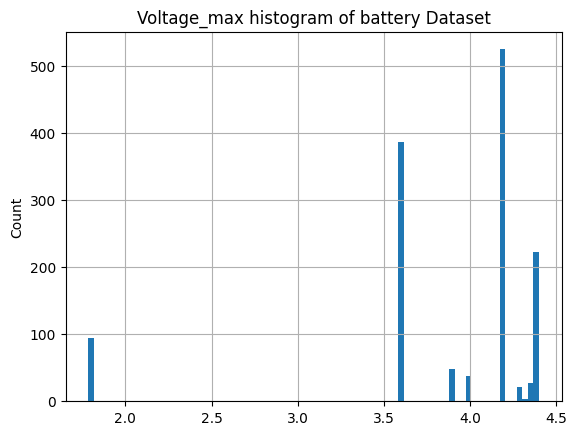

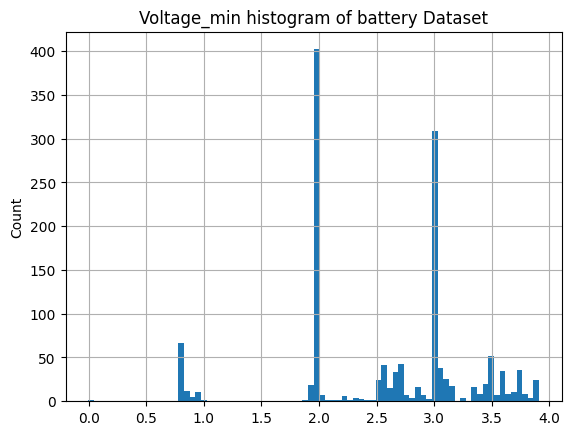

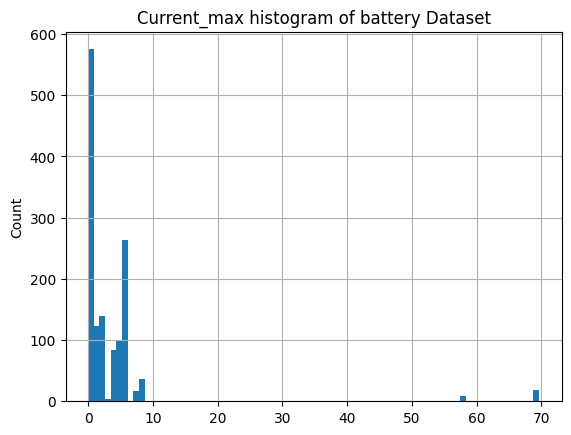

Max cycle life in dataset: 0.5730730295181274 cycles


In [44]:
print(f"Stats on data--> Cap_max: {max_dataset_capacity}, Cap_min: {min_dataset_capacity}, V_max: {max_dataset_voltage} V_min: {min_dataset_voltage} I_max: {max_dataset_current} I_min: {min_dataset_current}")   

# X_tensor[:, 0, 3, :] = X_tensor[:, 0, 3, :] / max_dataset_capacity

    # ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import scipy



##Adding back abs_capcity to the capcioty curve...



plt.hist(X_tensor[:,0,3,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Capacity histogram of battery Dataset")
plt.hist(X_tensor[:,0,2,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Capacity CURVE histogram of battery Dataset")
plt.show()
plt.hist(X_tensor[:,0,1,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Voltage_max histogram of battery Dataset")
plt.show()
plt.hist(X_tensor[:,0,1,:].min(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Voltage_min histogram of battery Dataset")
plt.show()
plt.hist(X_tensor[:,0,0,:].max(dim=-1).values * X_tensor[:,0,3,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Current_max histogram of battery Dataset")
plt.show()

X_tensor[:,0,2,:] = X_tensor[:,0,2,:] * X_tensor[:,0,3,:]
y_max = y_tensor.max()
print(f"Max cycle life in dataset: {y_max.item()} cycles")



In [47]:

## Almosft by look, because the first dim is the battery instance, the max < lim condition can be used as a mask for the array of tensors indexed only by first dim...
cap_lim = 20
X_filtered = X_tensor[(X_tensor[:,0,3,:].max(dim=-1).values < cap_lim) & (X_tensor[:,0,1,:].min(dim=-1).values > 1)]
Y_filtered = y_tensor[(X_tensor[:,0,3,:].max(dim=-1).values < cap_lim) & (X_tensor[:,0,1,:].min(dim=-1).values > 1)]
#X_filtered = X_tensor
#Y_filtered = y_tensor
plt.hist(X_filtered[:,0,3,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Capacity histogram of battery Dataset")
plt.show()
plt.hist(X_filtered[:,0,3,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Capacity histogram of battery Dataset")
plt.show()
plt.hist(X_filtered[:,0,1,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Voltage_max histogram of battery Dataset")
plt.show()
plt.hist(X_filtered[:,0,1,:].min(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Voltage_min histogram of battery Dataset")
plt.show()
plt.hist(X_filtered[:,0,0,:].max(dim=-1).values * X_filtered[:,0,3,:].max(dim=-1).values, bins = 80)
plt.ylabel("Count")
plt.grid(True)
plt.title("Current_max histogram of battery Dataset")
plt.show()

## Trying the normal normailisation for each input (Current is still converted to C prior)


##Good looking values, the fact the mean of the C_rates is near 0 is good, as all charging needs discharging!
voltage_mean = X_filtered[:,0,1,:].sum() / (len(X_filtered[:,0,1,0]) * len(X_filtered[0,0,1,:])) #Probs not the best way but it works
print(f"Votlage mean: {voltage_mean}")
C_mean = X_filtered[:,0,0,:].sum() / (len(X_filtered[:,0,0,0])* len(X_filtered[0,0,0,:]))
print(f"C_rate mean: {C_mean}")
capacity_mean = X_filtered[:,0,2,:].sum() / (len(X_filtered[:,0,2,0])* len(X_filtered[0,0,2,:]))
print(f"Capacity mean: {capacity_mean}")
y_label_mean = y_tensor.mean()
print(f"Cycles to 80%% label mean: {y_label_mean}")

voltage_std = X_filtered[:,0,1,:].std()
print(f"Votlage std: {voltage_std}")
C_std = X_filtered[:,0,0,:].std()
print(f"C_rate std: {C_std}")
cap_std = X_filtered[:,0,2,:].std()
print(f"Capacity std: {cap_std}")
y_label_std = y_tensor.std()
print(f"Cycles to 80%% label std: {y_label_std}")

X_filtered[:,0,1,:] = (X_filtered[:,0,1,:] - voltage_mean)/voltage_std
X_filtered[:,0,0,:] = (X_filtered[:,0,0,:] - C_mean)/C_std
X_filtered[:,0,2,:] = (X_filtered[:,0,2,:] - capacity_mean)/cap_std

X_filtered = X_filtered[:,:,0:3,:]
y_tensor_normalized = (y_tensor - y_label_mean)/y_label_std
# Create the dataset using the NORMALIZED labels
dataset = TensorDataset(X_filtered, y_tensor_normalized)
print(f"Size of original data: {len(X_tensor[:,0,0,0])}, size of filtered dataset: {len(X_filtered[:,0,0,0])}")

# Spliting data (950 for training, the rest for validation)
train_size = 1150
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=50, shuffle=True, num_workers=0)
validation_loader = DataLoader(val_data, batch_size=50, shuffle=False, num_workers=0)


IndexError: The shape of the mask [1366] at index 0 does not match the shape of the indexed tensor [2, 1] at index 0

In [24]:
x_tensor = torch.rand(2,3,10)
y_tensor = torch.rand(2,1)
test=  TensorDataset(x_tensor,y_tensor)
out = next(iter(test))
print(out)

(tensor([[0.5808, 0.1948, 0.7462, 0.5812, 0.0042, 0.4158, 0.7822, 0.5571, 0.0023,
         0.9252],
        [0.8328, 0.8209, 0.6199, 0.0048, 0.1783, 0.3374, 0.5711, 0.7842, 0.1999,
         0.4663],
        [0.3703, 0.8659, 0.4935, 0.6296, 0.4486, 0.2042, 0.9969, 0.9758, 0.3320,
         0.0271]]), tensor([0.1029]))


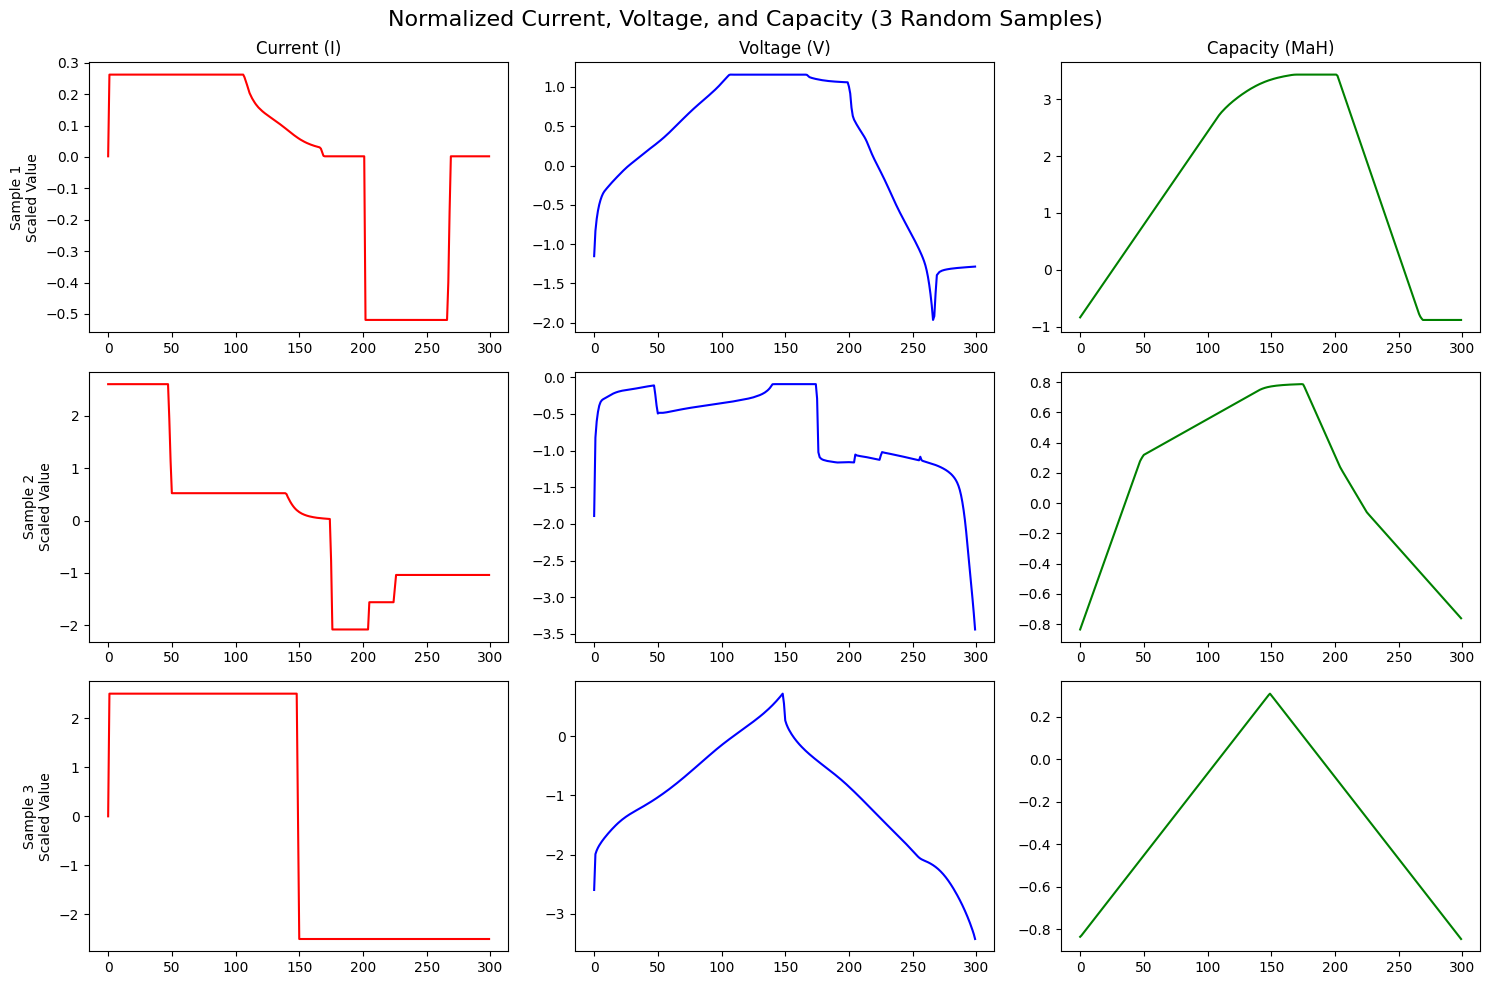

: 

In [ ]:
import matplotlib.pyplot as plt
import random

## Used gemini here as i really lost patientce for grpahing

# Grab a single batch of data
train_features, train_labels = next(iter(train_loader))

# Set up the plot to show 3 random batteries to see if they are squashed
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Normalized Current, Voltage, and Capacity (3 Random Samples)", fontsize=16)

for i in range(3):
    # Pick a random battery from this batch
    idx = random.randint(0, train_features.size(0) - 1)
    
    # Squeeze out the channel dim -> Shape: [3, 300]
    sample = train_features[idx].squeeze(0).numpy() 
    
    current = sample[0]
    voltage = sample[1]
    capacity = sample[2]
    
    time_steps = range(300)
    
    # Plot Current
    axes[i, 0].plot(time_steps, current, color='red')
    axes[i, 0].set_ylabel(f"Sample {i+1}\nScaled Value")
    if i == 0: axes[i, 0].set_title("Current (I)")
    
    # Plot Voltage
    axes[i, 1].plot(time_steps, voltage, color='blue')
    if i == 0: axes[i, 1].set_title("Voltage (V)")
    
    # Plot Capacity
    axes[i, 2].plot(time_steps, capacity, color='green')
    if i == 0: axes[i, 2].set_title("Capacity (MaH)")

plt.tight_layout()
plt.show()

In [57]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels}")
print(f"Squeezed shape: {train_features.squeeze(1).shape}")

Feature batch shape: torch.Size([50, 1, 3, 300])
Labels batch shape: tensor([ 0.9778, -0.9049, -1.0201,  0.4094, -0.4548, -0.9703, -0.5000,  0.3954,
         0.5138, -0.5654, -0.0827,  0.3487, -0.6542,  0.1945, -0.1823,  0.9701,
         0.3285,  1.6007, -0.5841, -0.1169, -0.4237, -0.2446,  1.5525,  1.7424,
        -1.0513,  0.0310, -0.5747, -0.4953, -0.3380,  0.2880, -0.9952, -0.1216,
         0.1587, -0.1823, -0.7554, -0.2384, -0.1091, -0.9220, -0.6713,  0.4515,
         0.1260, -0.4595,  0.1868,  2.7905, -0.0842, -0.2680,  2.8497, -0.5654,
        -1.0139, -0.7165])
Squeezed shape: torch.Size([50, 3, 300])


Using cuda, gpu -> NVIDIA GeForce RTX 5080
Epoch 0 --- Training Error: 417.5 Validation Error: 462.1 cycles
Epoch 10 --- Training Error: 380.4 Validation Error: 449.6 cycles
Epoch 20 --- Training Error: 372.3 Validation Error: 455.7 cycles
Epoch 30 --- Training Error: 375.2 Validation Error: 453.8 cycles
Epoch 40 --- Training Error: 364.2 Validation Error: 453.3 cycles
Epoch 50 --- Training Error: 366.6 Validation Error: 448.6 cycles
Epoch 60 --- Training Error: 370.5 Validation Error: 448.7 cycles
Epoch 70 --- Training Error: 364.9 Validation Error: 455.9 cycles
Epoch 80 --- Training Error: 356.3 Validation Error: 457.6 cycles
Epoch 90 --- Training Error: 365.8 Validation Error: 452.7 cycles
Epoch 100 --- Training Error: 365.3 Validation Error: 461.0 cycles
Epoch 110 --- Training Error: 358.1 Validation Error: 457.0 cycles
Epoch 120 --- Training Error: 366.7 Validation Error: 457.8 cycles
Epoch 130 --- Training Error: 364.7 Validation Error: 451.7 cycles
Epoch 140 --- Training Error: 

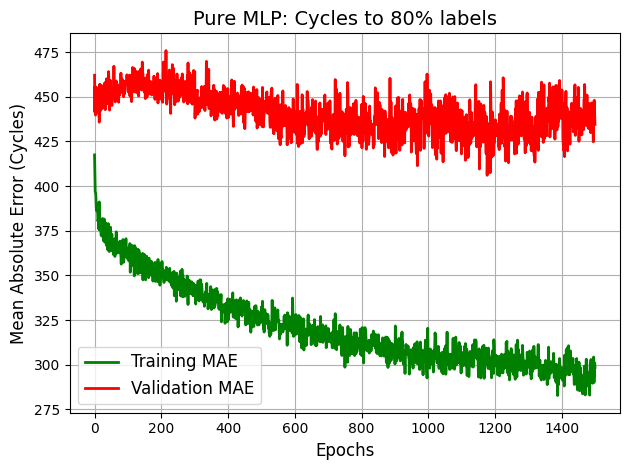

In [41]:

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}, gpu -> {torch.cuda.get_device_name(0) if torch.cuda.is_available() is True else 'N/A'}")
# y_max = y_max.to(device) # Make sure y_max is defined if you use it!

class MLPnetwork(nn.Module):
    def __init__(self, input_features=900, hidden_sizes=[1500, 645, 64]):
        super(MLPnetwork, self).__init__()

        # A pure MLP using only Linear layers and activations
        self.mlp = nn.Sequential(
            nn.Linear(input_features, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_sizes[2], 1)  # Final output layer
        )

    def forward(self, x):
        # x comes in as [batch, 1, 3, 300] (based on your dataloader)
        # We must flatten it to [batch, 900] so the Linear layer can process it
        x = x.view(x.size(0), -1) 
        
        cycle_to_80_pred = self.mlp(x) 
        return cycle_to_80_pred.flatten()

# Initialize the pure MLP (3 channels * 300 time steps = 900 input features)
model = MLPnetwork(input_features=900).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=4e-4)
criterion = nn.MSELoss()
epochs = 1500

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):

    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)    
        optimizer.zero_grad()
        
        preds = model(batch_x)   

        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)


    model.eval()
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ---", f"Training Error: {avg_train_mae:.1f}", f"Validation Error: {avg_val_mae:.1f} cycles")

# Plotting the MLP results
plt.figure()
plt.plot(train_mae_history, label='Training MAE', color='green', linewidth=2)
plt.plot(val_mae_history, label='Validation MAE', color='red', linewidth=2)

plt.title('Pure MLP: Cycles to 80% labels', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

In [42]:
import pandas as pd

# Create a DataFrame from your MAE history lists
mae_df = pd.DataFrame({
    'Epoch': range(epochs),
    'Train_MAE': train_mae_history,
    'Val_MAE': val_mae_history
})

# Export to CSV (index=False prevents pandas from writing row numbers)
csv_filename = "mae_history.csv"
mae_df.to_csv(csv_filename, index=False)

print(f"Data successfully exported to {csv_filename}!")


Data successfully exported to mae_history.csv!


In [34]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt # <--- Added for plotting

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}, gpu -> {torch.cuda.get_device_name(0) if torch.cuda.is_available() is True else 'N/A'}")
y_max = y_max.to(device)

class LSTMnetwork(nn.Module):
    def __init__(self, hidden_size=110, num_layers=2):
        super(LSTMnetwork, self).__init__()

        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2
        )
        
        self.out = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), 
            nn.ReLU(),                                
            nn.Dropout(0.2),                          
            nn.Linear(hidden_size // 2, 1)            # Final output layer
        )

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1) 
        _, (hidden_layers, _) = self.lstm(x)
        cycle_to_80_pred = self.out(hidden_layers[-1]) 

        return cycle_to_80_pred.flatten()

model = LSTMnetwork(hidden_size=150, num_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()
epochs = 500

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):

    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)    
        optimizer.zero_grad()
        
        preds = model(batch_x)   

        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)


    model.eval()
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ---", f"Training Error: {avg_train_mae:.1f}", f"Validation Error: {avg_val_mae:.1f} cycles")

plt.figure()
plt.plot(train_mae_history, label='Training MAE', color='green', linewidth=2)
plt.plot(val_mae_history, label='Validation MAE', color='red', linewidth=2)

plt.title('LSTM: Cylcels to 80%% labels', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Using cuda, gpu -> NVIDIA GeForce RTX 5080
Epoch 0 --- Training Error: 439.9 Validation Error: 481.8 cycles
Epoch 10 --- Training Error: 390.9 Validation Error: 453.2 cycles
Epoch 20 --- Training Error: 398.1 Validation Error: 456.1 cycles
Epoch 30 --- Training Error: 408.6 Validation Error: 483.7 cycles
Epoch 40 --- Training Error: 443.5 Validation Error: 481.3 cycles
Epoch 50 --- Training Error: 439.8 Validation Error: 482.0 cycles
Epoch 60 --- Training Error: 443.0 Validation Error: 483.5 cycles


KeyboardInterrupt: 

In [37]:
import torch
import torch.nn as nn
import math

# ==========================
# 1. POSITIONAL ENCODING
# ==========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ==========================
# 2. TRANSFORMER NETWORK
# ==========================
class TransformerNetwork(nn.Module):
    def __init__(self, input_size=3, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()

        # ---- Multi-scale convolutional embedding ----
        self.conv_small = nn.Conv1d(input_size, d_model//2, kernel_size=3, padding=1)
        self.conv_large = nn.Conv1d(input_size, d_model//2, kernel_size=11, padding=5)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Attention pooling
        self.attention_pool = nn.Linear(d_model, 1)

        # Output head
        self.out = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, 1)
        )

    def forward(self, x):
        # x shape: [batch, 1, channels, sequence_length] -> squeeze if needed
        x = x.squeeze(1)  # [batch, channels, seq_len]
        
        # Multi-scale convolution
        x_small = self.conv_small(x)
        x_large = self.conv_large(x)
        x = torch.cat([x_small, x_large], dim=1)  # [batch, d_model, seq_len]
        
        # Transformer expects [batch, seq_len, d_model]
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # Attention pooling
        attn_weights = torch.softmax(self.attention_pool(x), dim=1)  # [batch, seq_len, 1]
        x = torch.sum(attn_weights * x, dim=1)  # [batch, d_model]

        pred = self.out(x)
        return pred.flatten()

# ==========================
# 3. SETUP 
# ==========================
model = TransformerNetwork(
    input_size=3,    # UPDATED to 3 channels (Voltage, Current, Capacity)
    d_model=120,      # Reduced to prevent overfitting
    nhead=4,         
    num_layers=3,    # Reduced to prevent overfitting
    dropout=0.3
).to(device)

# Added weight_decay (L2 regularization) to help prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4) 
criterion = nn.MSELoss()

# ==========================
# 4. TRAINING & VALIDATION LOOP
# ==========================
epochs = 500 # Reduced epochs (transformers can learn fast, but also overfit fast!)

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_x)   
        
        loss = criterion(preds, batch_y)
        loss.backward()
        
        # CRUCIAL FIX FOR TRANSFORMERS: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            # CHANGED: Standard denormalization using mean and std
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            # CHANGED: Standard denormalization using mean and std
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    # Print every 10 epochs to keep the console clean
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:04d} | Train Error: {avg_train_mae:.1f} cycles | Val Error: {avg_val_mae:.1f} cycles")

# ==========================
# 5. PLOT RESULTS
# ==========================
plt.figure(figsize=(10, 6))
plt.plot(train_mae_history, label='Training MAE', color='blue', linewidth=1.5)
plt.plot(val_mae_history, label='Validation MAE', color='orange', linewidth=1.5)

plt.title('Transformer Learning Curve: Cycle Life Prediction', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Epoch 0000 | Train Error: 428.3 cycles | Val Error: 472.3 cycles
Epoch 0010 | Train Error: 402.1 cycles | Val Error: 450.4 cycles
Epoch 0020 | Train Error: 384.4 cycles | Val Error: 442.3 cycles
Epoch 0030 | Train Error: 378.8 cycles | Val Error: 463.0 cycles


KeyboardInterrupt: 

In [36]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================
# 2. SETUP (Updated with Scheduler)
# ==========================
model = BatteryRULPredictor(
    input_channels=3, 
    hidden_size=75,   
    num_layers=3, 
    dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4) 
criterion = nn.MSELoss()


# ==========================
# 3. TRAINING & VALIDATION LOOP (Updated with Early Stopping)
# ==========================
epochs = 500 

train_mae_history = []
val_mae_history = []

# NEW: Early Stopping Tracking Variables
best_val_mae = float('inf')
patience_counter = 0
early_stopping_patience = 500 # Stop completely if no improvement for 30 epochs
best_model_path = 'best_battery_rul_model.pth'

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_x)   
        
        loss = criterion(preds, batch_y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)
    
    # NEW: Step the scheduler based on Validation MAE

    # NEW: Early Stopping & Model Saving Logic
    if avg_val_mae < best_val_mae:
        best_val_mae = avg_val_mae
        patience_counter = 0
        # Save the weights of the best performing model
        torch.save(model.state_dict(), best_model_path)
        status = "(New Best! Saved)"
    else:
        patience_counter += 1
        status = f"(Patience: {patience_counter}/{early_stopping_patience})"

    # Print progress
    if epoch % 5 == 0 or epoch == epochs - 1 or patience_counter == 0:
        print(f"Epoch {epoch:03d} | Train MAE: {avg_train_mae:.1f} | Val MAE: {avg_val_mae:.1f} {status}")

    # Trigger Early Stopping
    if patience_counter >= early_stopping_patience:
        print(f"\n--- Early stopping triggered at epoch {epoch} ---")
        print(f"Best Validation MAE achieved: {best_val_mae:.1f}")
        break

# ==========================
# 4. LOAD BEST MODEL & PLOT
# ==========================
# NEW: Load the best weights back into the model for future inference
print("Loading best model weights...")
model.load_state_dict(torch.load(best_model_path))
model.eval()

plt.figure(figsize=(10, 6))
plt.plot(train_mae_history, label='Training MAE', color='blue', linewidth=1.5)
plt.plot(val_mae_history, label='Validation MAE', color='orange', linewidth=1.5)

# Add a marker for where the best model was saved
best_epoch = len(val_mae_history) - patience_counter - 1
if early_stopping_patience > patience_counter: # if it didn't early stop
    pass 
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

plt.title('CNN-LSTM Learning Curve: Cycle Life Prediction', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'BatteryRULPredictor' is not defined

Using cuda, gpu -> NVIDIA GeForce RTX 5080
Epoch 0 --- Training Error: 435.9 Validation Error: 469.7 cycles
Epoch 10 --- Training Error: 385.6 Validation Error: 444.2 cycles
Epoch 20 --- Training Error: 380.3 Validation Error: 442.1 cycles
Epoch 30 --- Training Error: 376.9 Validation Error: 439.5 cycles
Epoch 40 --- Training Error: 367.2 Validation Error: 443.1 cycles
Epoch 50 --- Training Error: 365.2 Validation Error: 442.8 cycles
Epoch 60 --- Training Error: 366.5 Validation Error: 444.3 cycles
Epoch 70 --- Training Error: 367.6 Validation Error: 449.9 cycles
Epoch 80 --- Training Error: 360.7 Validation Error: 450.4 cycles
Epoch 90 --- Training Error: 361.1 Validation Error: 456.4 cycles
Epoch 100 --- Training Error: 355.6 Validation Error: 458.2 cycles
Epoch 110 --- Training Error: 354.3 Validation Error: 453.0 cycles
Epoch 120 --- Training Error: 353.4 Validation Error: 454.7 cycles
Epoch 130 --- Training Error: 352.8 Validation Error: 461.6 cycles
Epoch 140 --- Training Error: 

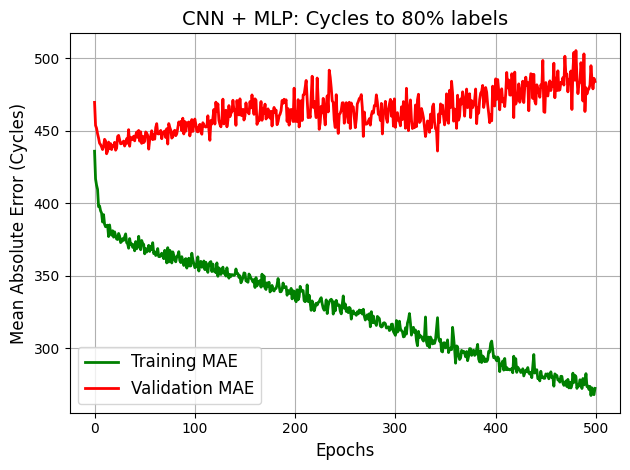

In [38]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}, gpu -> {torch.cuda.get_device_name(0) if torch.cuda.is_available() is True else 'N/A'}")
# y_max = y_max.to(device)

class CNN_MLP_Network(nn.Module):
    def __init__(self, input_channels=3):
        super(CNN_MLP_Network, self).__init__()

        # --- 1. CNN Feature Extractor ---
        self.cnn = nn.Sequential(
            # Layer 1
            nn.Conv1d(in_channels=input_channels, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            # Layer 2
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            # Layer 3
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # Adaptive pooling ensures the CNN output is ALWAYS length 10, 
        # regardless of whether your input sequence is 300 or 500 steps.
        self.adaptive_pool = nn.AdaptiveAvgPool1d(10)
        
        # Flattened size = 64 channels * 10 length = 640
        flattened_size = 640

        # --- 2. MLP Regression Head ---
        self.mlp = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)  # Final output layer
        )

    def forward(self, x):
        # x comes in as [batch, 1, 3, 300]
        # Remove the extra dimension so it becomes [batch, 3, 300]
        x = x.squeeze(1) 
        
        # Pass through CNN
        features = self.cnn(x)
        features = self.adaptive_pool(features)
        
        # Flatten the features: [batch, 64, 10] -> [batch, 640]
        features = features.view(features.size(0), -1)
        
        # Pass through MLP
        cycle_to_80_pred = self.mlp(features) 
        
        return cycle_to_80_pred.flatten()

# Initialize the model
model = CNN_MLP_Network(input_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()
epochs = 500

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):

    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)    
        optimizer.zero_grad()
        
        preds = model(batch_x)   

        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)


    model.eval()
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = (preds * y_label_std) + y_label_mean
            batch_y_real = (batch_y * y_label_std) + y_label_mean
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} --- Training Error: {avg_train_mae:.1f} Validation Error: {avg_val_mae:.1f} cycles")

# Plotting the CNN+MLP results
plt.figure()
plt.plot(train_mae_history, label='Training MAE', color='green', linewidth=2)
plt.plot(val_mae_history, label='Validation MAE', color='red', linewidth=2)

plt.title('CNN + MLP: Cycles to 80% labels', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()